# Tutorial: Testing for Proportional Covariance Matrices

This tutorial demonstrates how to test the null hypothesis:

$$H_0: \Sigma_1 = c \cdot \Sigma_2$$

for some unknown constant $c > 0$.

**Proportionality** means the two covariance matrices have the same *structure* (correlation pattern) but may differ in overall *scale*.

## When is this useful?

- **Treatment effects**: Test if a treatment changes variability scale but not correlation structure
- **Heteroscedasticity**: Allow for different variances while assuming same correlations
- **Time series**: Test if covariance structure is stable across periods (up to scale)
- **Group comparisons**: More flexible than equality testing

## Relationship to Other Tests

| Hypothesis | Meaning | Test Type |
|------------|---------|----------|
| Σ₁ = Σ₂ | Exactly equal | Two-sample equality |
| Σ₁ = c·Σ₂ | Same structure, different scale | Proportionality |
| Σ = σ²I | Spherical | Sphericity |

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import proportionality test functions
from covtest.methods.hypothesis_proportionality import (
    bartlett_adjusted_proportionality_test,
    proportionality_test_LZ,
    proportionality_test_signs,
    proportionality_plrt,
    proportional_cov_test_tsukuda
)

# Import data generation utilities
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    sample_cov_uniform_correlation
)

# Import real data loader
from covtest.datasets.loader import load_iris

# Set random seed
rng = np.random.default_rng(42)

print("Setup complete!")

Setup complete!


## 2. Available Tests Overview

| Function | Best For | Calibration |
|----------|----------|-------------|
| `bartlett_adjusted_proportionality_test` | Classical with correction | Bootstrap |
| `proportionality_test_LZ` | High-dimensional | Asymptotic normal |
| `proportionality_test_signs` | Robust, high-dimensional | Permutation/Asymptotic |
| `proportionality_plrt` | Pseudo-likelihood | Asymptotic normal |
| `proportional_cov_test_tsukuda` | Very high-dimensional | Trace-based |

## 3. Example 1: Proportional Covariances (Null is True)

In [2]:
# Generate two groups with PROPORTIONAL covariances
n1, n2, p = 100, 120, 10

# Base covariance structure (AR(1))
rho = 0.6
Sigma_base = generate_toeplitz_cov(p, rho)

# Group 1: Σ₁ = Sigma_base
# Group 2: Σ₂ = 3 × Sigma_base (proportional with c = 1/3)
scale_factor = 3.0
Sigma1 = Sigma_base
Sigma2 = scale_factor * Sigma_base

X = generate_heavy_tailed_samples(Sigma1, n1, 'normal', rng=rng)
Y = generate_heavy_tailed_samples(Sigma2, n2, 'normal', rng=rng)

print(f"Group 1: n={n1}, Σ₁ = AR(1) with ρ={rho}")
print(f"Group 2: n={n2}, Σ₂ = {scale_factor} × Σ₁")
print(f"\nTrue: Σ₁ = c·Σ₂ with c = {1/scale_factor:.3f}")
print("The covariances ARE proportional (null is TRUE)")

Group 1: n=100, Σ₁ = AR(1) with ρ=0.6
Group 2: n=120, Σ₂ = 3.0 × Σ₁

True: Σ₁ = c·Σ₂ with c = 0.333
The covariances ARE proportional (null is TRUE)


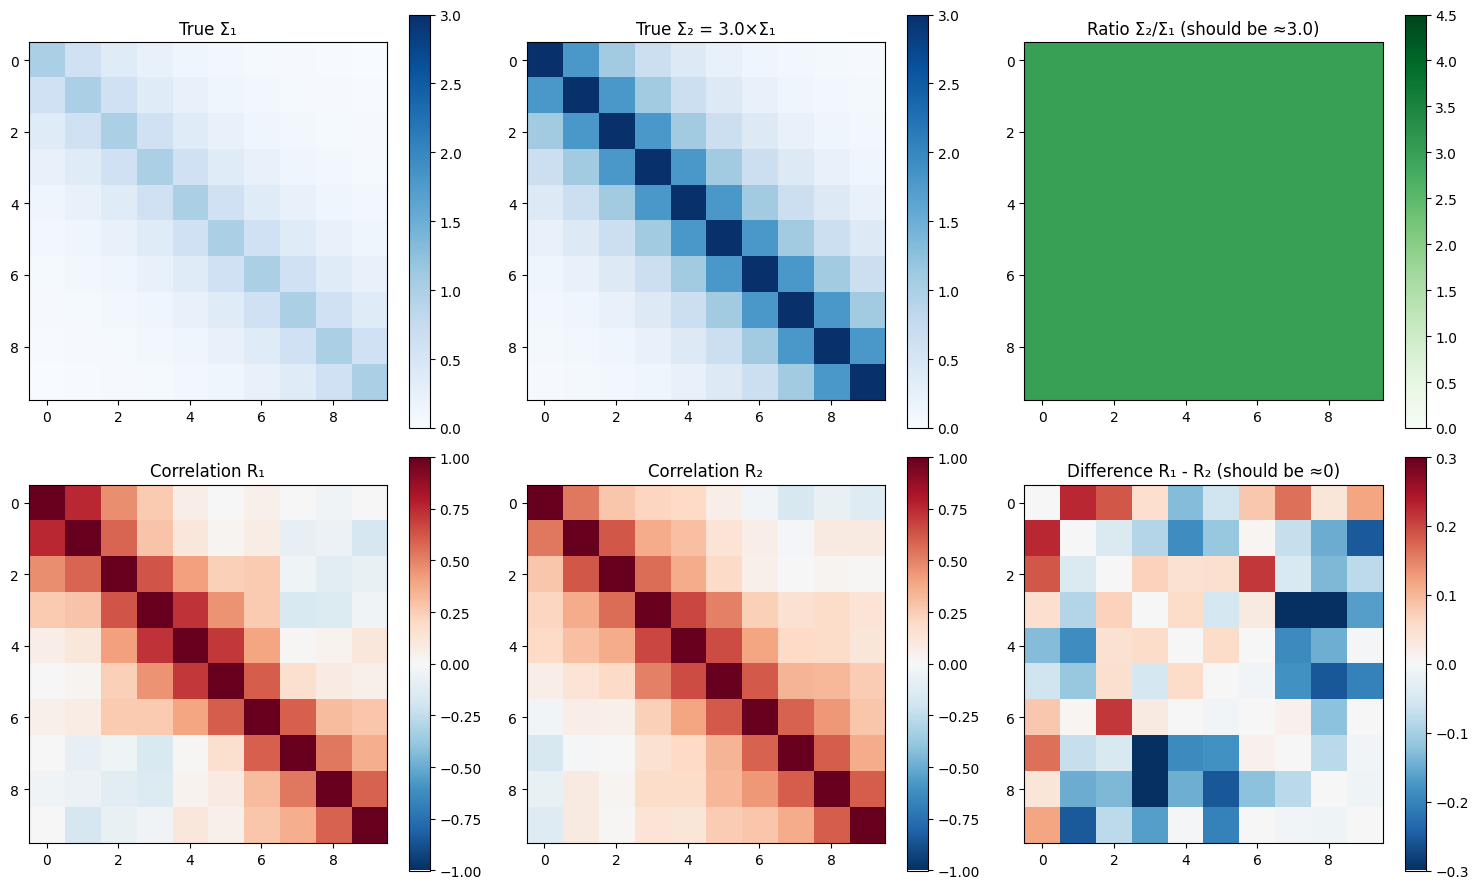

Estimated scale ratio (trace): 2.916 (true: 3.0)
Correlation difference norm: 1.2938


In [3]:
# Visualize proportional covariances
S1 = np.cov(X, rowvar=False)
S2 = np.cov(Y, rowvar=False)

# Compute correlation matrices (should be identical if proportional)
D1 = np.diag(1/np.sqrt(np.diag(S1)))
D2 = np.diag(1/np.sqrt(np.diag(S2)))
R1 = D1 @ S1 @ D1
R2 = D2 @ S2 @ D2

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# True covariances
vmax = max(Sigma1.max(), Sigma2.max())
im1 = axes[0, 0].imshow(Sigma1, cmap='Blues', vmin=0, vmax=vmax)
axes[0, 0].set_title('True Σ₁')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(Sigma2, cmap='Blues', vmin=0, vmax=vmax)
axes[0, 1].set_title(f'True Σ₂ = {scale_factor}×Σ₁')
plt.colorbar(im2, ax=axes[0, 1])

# Ratio should be constant
ratio = Sigma2 / (Sigma1 + 1e-10)
im3 = axes[0, 2].imshow(ratio, cmap='Greens', vmin=0, vmax=scale_factor*1.5)
axes[0, 2].set_title(f'Ratio Σ₂/Σ₁ (should be ≈{scale_factor})')
plt.colorbar(im3, ax=axes[0, 2])

# Correlation matrices (should be equal for proportional)
im4 = axes[1, 0].imshow(R1, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 0].set_title('Correlation R₁')
plt.colorbar(im4, ax=axes[1, 0])

im5 = axes[1, 1].imshow(R2, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_title('Correlation R₂')
plt.colorbar(im5, ax=axes[1, 1])

im6 = axes[1, 2].imshow(R1 - R2, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 2].set_title('Difference R₁ - R₂ (should be ≈0)')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

print(f"Estimated scale ratio (trace): {np.trace(S2)/np.trace(S1):.3f} (true: {scale_factor})")
print(f"Correlation difference norm: {np.linalg.norm(R1 - R2, 'fro'):.4f}")

In [4]:
# Run proportionality tests when null is TRUE
print("="*65)
print("Testing H₀: Σ₁ = c·Σ₂ (NULL IS TRUE)")
print("="*65)

tests = [
    ("Liu-Zheng (LZ)", proportionality_test_LZ),
    ("Signs (permutation)", lambda X, Y: proportionality_test_signs(X, Y, calibration='permutation', n_perm=499)),
    ("Signs (asymptotic)", lambda X, Y: proportionality_test_signs(X, Y, calibration='asymp_spherical')),
    ("PLRT", proportionality_plrt),
    ("Tsukuda", proportional_cov_test_tsukuda),
]

for name, test_func in tests:
    try:
        result = test_func(X, Y)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should FAIL TO REJECT H₀")

Testing H₀: Σ₁ = c·Σ₂ (NULL IS TRUE)
Flury               : p-value=0.0218 → Reject H₀
Liu-Zheng (LZ)      : p-value=0.2195 → Fail to reject H₀
Signs (permutation) : p-value=0.1860 → Fail to reject H₀
Signs (asymptotic)  : p-value=0.0925 → Fail to reject H₀
PLRT                : p-value=0.0713 → Fail to reject H₀
Tsukuda             : p-value=0.4555 → Fail to reject H₀

✓ Expected: All tests should FAIL TO REJECT H₀


## 4. Example 2: Non-Proportional Covariances (Null is False)

In [5]:
# Generate two groups with NON-PROPORTIONAL covariances
n1, n2, p = 100, 120, 10

# Group 1: AR(1) with rho=0.3
Sigma1_diff = generate_toeplitz_cov(p, rho=0.3)

# Group 2: AR(1) with rho=0.8 (DIFFERENT structure, not just scale)
Sigma2_diff = generate_toeplitz_cov(p, rho=0.8)

X_diff = generate_heavy_tailed_samples(Sigma1_diff, n1, 'normal', rng=rng)
Y_diff = generate_heavy_tailed_samples(Sigma2_diff, n2, 'normal', rng=rng)

print(f"Group 1: AR(1) with ρ=0.3")
print(f"Group 2: AR(1) with ρ=0.8")
print(f"\nThese have DIFFERENT correlation structures")
print("The covariances are NOT proportional (null is FALSE)")

Group 1: AR(1) with ρ=0.3
Group 2: AR(1) with ρ=0.8

These have DIFFERENT correlation structures
The covariances are NOT proportional (null is FALSE)


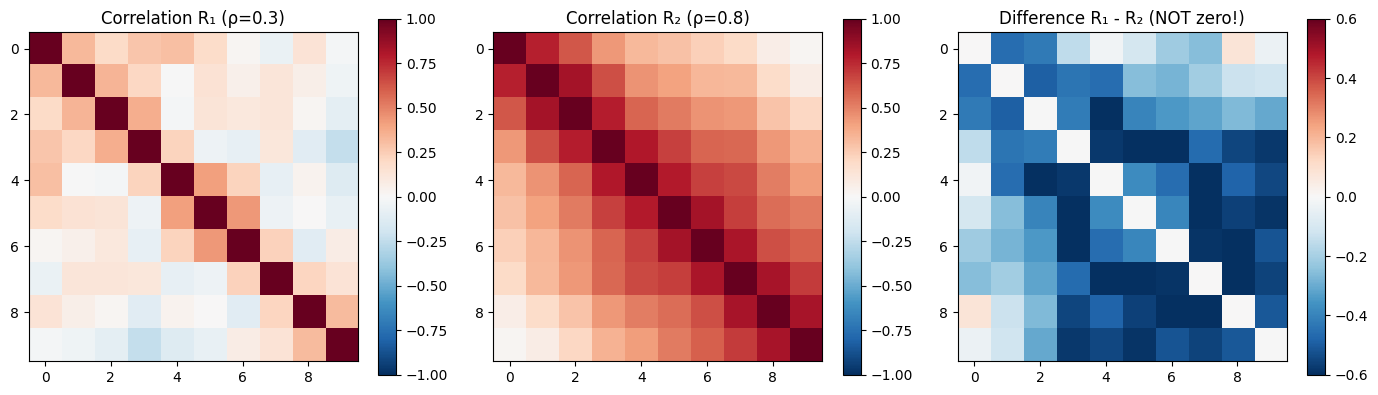

Correlation difference norm: 4.3780
(Large value indicates different structures)


In [6]:
# Visualize non-proportional covariances
S1_diff = np.cov(X_diff, rowvar=False)
S2_diff = np.cov(Y_diff, rowvar=False)

# Correlation matrices
D1_diff = np.diag(1/np.sqrt(np.diag(S1_diff)))
D2_diff = np.diag(1/np.sqrt(np.diag(S2_diff)))
R1_diff = D1_diff @ S1_diff @ D1_diff
R2_diff = D2_diff @ S2_diff @ D2_diff

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im1 = axes[0].imshow(R1_diff, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Correlation R₁ (ρ=0.3)')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(R2_diff, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Correlation R₂ (ρ=0.8)')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(R1_diff - R2_diff, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
axes[2].set_title('Difference R₁ - R₂ (NOT zero!)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Correlation difference norm: {np.linalg.norm(R1_diff - R2_diff, 'fro'):.4f}")
print("(Large value indicates different structures)")

In [7]:
# Run proportionality tests when null is FALSE
print("="*65)
print("Testing H₀: Σ₁ = c·Σ₂ (NULL IS FALSE)")
print("="*65)

for name, test_func in tests:
    try:
        result = test_func(X_diff, Y_diff)
        decision = "Reject H₀ ✓" if result['p_value'] < 0.05 else "Fail to reject ✗"
        print(f"{name:20s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:40]}")

print("\n✓ Expected: All tests should REJECT H₀")

Testing H₀: Σ₁ = c·Σ₂ (NULL IS FALSE)
Flury               : p-value=0.0000 → Reject H₀ ✓
Liu-Zheng (LZ)      : p-value=0.0000 → Reject H₀ ✓
Signs (permutation) : p-value=0.0020 → Reject H₀ ✓
Signs (asymptotic)  : p-value=0.0000 → Reject H₀ ✓
PLRT                : p-value=0.0000 → Reject H₀ ✓
Tsukuda             : p-value=0.0000 → Reject H₀ ✓

✓ Expected: All tests should REJECT H₀


## 5. Comparison: Proportionality vs Equality Tests

In [8]:
# Key insight: Proportional ≠ Equal
# If covariances are proportional but not equal, 
# proportionality test should NOT reject, but equality test SHOULD reject

from covtest.methods.hypothesis_two_sample import boxm_test, schott2007

print("PROPORTIONAL BUT NOT EQUAL (Σ₂ = 3×Σ₁)")
print("="*65)

print("\nEquality tests (H₀: Σ₁ = Σ₂):")
equality_tests = [
    ("Box's M", lambda X, Y: boxm_test(X, Y, type='chi.squared')),
    ("Schott 2007", schott2007),
]
for name, test_func in equality_tests:
    try:
        result = test_func(X, Y)
        decision = "Reject" if result['p_value'] < 0.05 else "Fail to reject"
        print(f"  {name:15s}: p={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"  {name:15s}: Error")

print("\nProportionality tests (H₀: Σ₁ = c·Σ₂):")
for name, test_func in tests[:3]:
    try:
        result = test_func(X, Y)
        decision = "Reject" if result['p_value'] < 0.05 else "Fail to reject"
        print(f"  {name:15s}: p={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"  {name:15s}: Error")

print("\n→ Equality tests REJECT (Σ₁ ≠ Σ₂)")
print("→ Proportionality tests do NOT reject (Σ₁ ∝ Σ₂)")

PROPORTIONAL BUT NOT EQUAL (Σ₂ = 3×Σ₁)

Equality tests (H₀: Σ₁ = Σ₂):
  Box's M        : p=0.0000 → Reject
  Schott 2007    : p=0.0000 → Reject

Proportionality tests (H₀: Σ₁ = c·Σ₂):
  Flury          : p=0.0218 → Reject
  Liu-Zheng (LZ) : p=0.2195 → Fail to reject
  Signs (permutation): p=0.2020 → Fail to reject

→ Equality tests REJECT (Σ₁ ≠ Σ₂)
→ Proportionality tests do NOT reject (Σ₁ ∝ Σ₂)


## 6. Example 3: High-Dimensional Setting

In [9]:
# High-dimensional case
n1_hd, n2_hd, p_hd = 80, 80, 50  # p/n ≈ 0.625

# Proportional (null true)
Sigma_hd = generate_toeplitz_cov(p_hd, rho=0.5)
X_hd_prop = generate_heavy_tailed_samples(Sigma_hd, n1_hd, 'normal', rng=rng)
Y_hd_prop = generate_heavy_tailed_samples(2.5 * Sigma_hd, n2_hd, 'normal', rng=rng)

# Non-proportional (null false)
Sigma_hd_1 = generate_toeplitz_cov(p_hd, rho=0.3)
Sigma_hd_2 = generate_toeplitz_cov(p_hd, rho=0.7)
X_hd_diff = generate_heavy_tailed_samples(Sigma_hd_1, n1_hd, 'normal', rng=rng)
Y_hd_diff = generate_heavy_tailed_samples(Sigma_hd_2, n2_hd, 'normal', rng=rng)

print(f"High-dimensional: n₁={n1_hd}, n₂={n2_hd}, p={p_hd}")
print(f"Ratio p/n: {p_hd/n1_hd:.2f}")

High-dimensional: n₁=80, n₂=80, p=50
Ratio p/n: 0.62


In [10]:
# Tests suitable for high dimensions
hd_tests = [
    ("Liu-Zheng (LZ)", proportionality_test_LZ),
    ("Signs (asymptotic)", lambda X, Y: proportionality_test_signs(X, Y, calibration='asymp_spherical')),
    ("Tsukuda", proportional_cov_test_tsukuda),
]

print("HIGH-DIMENSIONAL PROPORTIONALITY TESTS (p/n ≈ 0.625)")
print("="*65)

print("\n--- Null TRUE (Σ₂ = 2.5×Σ₁) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_prop, Y_hd_prop)
        status = "✓" if result['p_value'] > 0.05 else "✗ (Type I)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:35]}")

print("\n--- Null FALSE (Different structures) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_diff, Y_hd_diff)
        status = "✓" if result['p_value'] < 0.05 else "✗ (missed)"
        print(f"{name:20s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:20s}: Error - {str(e)[:35]}")

HIGH-DIMENSIONAL PROPORTIONALITY TESTS (p/n ≈ 0.625)

--- Null TRUE (Σ₂ = 2.5×Σ₁) ---
Liu-Zheng (LZ)      : p-value=0.3377 ✓
Signs (asymptotic)  : p-value=0.7992 ✓
Tsukuda             : p-value=0.6339 ✓

--- Null FALSE (Different structures) ---
Liu-Zheng (LZ)      : p-value=0.2525 ✗ (missed)
Signs (asymptotic)  : p-value=0.0000 ✓
Tsukuda             : p-value=0.0000 ✓


## 7. Example 4: Robustness to Heavy Tails

In [11]:
# Proportional covariances with heavy-tailed data
n1, n2, p = 100, 100, 12
Sigma = generate_toeplitz_cov(p, rho=0.5)
Sigma_scaled = 2.0 * Sigma

# Normal
X_norm = generate_heavy_tailed_samples(Sigma, n1, 'normal', rng=rng)
Y_norm = generate_heavy_tailed_samples(Sigma_scaled, n2, 'normal', rng=rng)

# Heavy-tailed (t with df=3)
X_t3 = generate_heavy_tailed_samples(Sigma, n1, 't', rng=rng, options={'df': 3})
Y_t3 = generate_heavy_tailed_samples(Sigma_scaled, n2, 't', rng=rng, options={'df': 3})

print("All pairs have PROPORTIONAL covariances (Σ₂ = 2×Σ₁)")
print("Testing robustness to distribution")

All pairs have PROPORTIONAL covariances (Σ₂ = 2×Σ₁)
Testing robustness to distribution


In [12]:
# Compare robustness
robust_tests = [
    ("Signs (perm)", lambda X, Y: proportionality_test_signs(X, Y, calibration='permutation', n_perm=299)),
    ("Tsukuda", proportional_cov_test_tsukuda),
]

print("ROBUSTNESS COMPARISON (Null TRUE for all)")
print("="*60)
print(f"{'Test':<18} {'Normal':>15} {'t(df=3)':>15}")
print("-"*60)

for name, test_func in robust_tests:
    try:
        p_norm = test_func(X_norm, Y_norm)['p_value']
        p_t3 = test_func(X_t3, Y_t3)['p_value']
        
        status_norm = "✓" if p_norm > 0.05 else "✗"
        status_t3 = "✓" if p_t3 > 0.05 else "✗"
        
        print(f"{name:<18} {p_norm:>12.4f} {status_norm}  {p_t3:>12.4f} {status_t3}")
    except Exception as e:
        print(f"{name:<18} Error: {str(e)[:25]}")

print("\n✓ = Correctly failed to reject, ✗ = False rejection")
print("Note: Signs test (spatial signs) is designed to be robust")

ROBUSTNESS COMPARISON (Null TRUE for all)
Test                        Normal         t(df=3)
------------------------------------------------------------
Flury                    0.2622 ✓        0.0000 ✗
Signs (perm)             0.5200 ✓        0.9467 ✓
Tsukuda                  0.3241 ✓        0.0037 ✗

✓ = Correctly failed to reject, ✗ = False rejection
Note: Signs test (spatial signs) is designed to be robust


## 8. Real Data Example: Iris Dataset

In [13]:
# Load Iris and test proportionality between species
X_iris, y_iris, feature_names, target_names = load_iris(return_names=True)

# Extract data for each species
X_setosa = X_iris[y_iris == 0]
X_versicolor = X_iris[y_iris == 1]
X_virginica = X_iris[y_iris == 2]

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"\nComparing covariance structures between species")

Iris dataset: 150 samples, 4 features

Comparing covariance structures between species


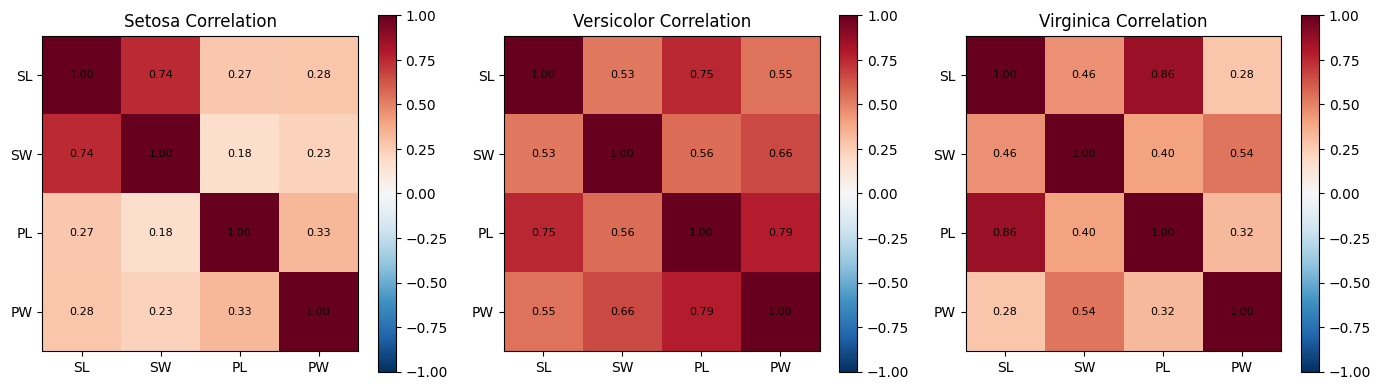

In [14]:
# Visualize correlation structures
def get_corr(X):
    S = np.cov(X, rowvar=False)
    D = np.diag(1/np.sqrt(np.diag(S)))
    return D @ S @ D

R_set = get_corr(X_setosa)
R_ver = get_corr(X_versicolor)
R_vir = get_corr(X_virginica)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = ['SL', 'SW', 'PL', 'PW']
for ax, R, title in zip(axes, [R_set, R_ver, R_vir], ['Setosa', 'Versicolor', 'Virginica']):
    im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'{title} Correlation')
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(4))
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax)
    
    # Add values
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# Test pairwise proportionality
pairs = [
    ("Setosa vs Versicolor", X_setosa, X_versicolor),
    ("Setosa vs Virginica", X_setosa, X_virginica),
    ("Versicolor vs Virginica", X_versicolor, X_virginica),
]

prop_tests = [
    ("Signs", lambda X, Y: proportionality_test_signs(X, Y, calibration='permutation', n_perm=499)),
    ("Tsukuda", proportional_cov_test_tsukuda),
]

print("PAIRWISE PROPORTIONALITY TESTS ON IRIS DATA")
print("="*70)

for pair_name, X_a, X_b in pairs:
    print(f"\n{pair_name}:")
    for test_name, test_func in prop_tests:
        try:
            result = test_func(X_a, X_b)
            decision = "Reject (not proportional)" if result['p_value'] < 0.05 else "Fail to reject (may be proportional)"
            print(f"  {test_name:10s}: p={result['p_value']:.4f} → {decision}")
        except Exception as e:
            print(f"  {test_name:10s}: Error - {str(e)[:30]}")

PAIRWISE PROPORTIONALITY TESTS ON IRIS DATA

Setosa vs Versicolor:
  Flury     : p=0.0000 → Reject (not proportional)
  Signs     : p=0.0020 → Reject (not proportional)
  Tsukuda   : p=0.0000 → Reject (not proportional)

Setosa vs Virginica:
  Flury     : p=0.0000 → Reject (not proportional)
  Signs     : p=0.0020 → Reject (not proportional)
  Tsukuda   : p=0.0000 → Reject (not proportional)

Versicolor vs Virginica:
  Flury     : p=0.0009 → Reject (not proportional)
  Signs     : p=0.4060 → Fail to reject (may be proportional)
  Tsukuda   : p=0.8628 → Fail to reject (may be proportional)


In [16]:
# Quantify how similar the correlation structures are
print("CORRELATION STRUCTURE COMPARISON")
print("="*50)
print(f"\n||R_setosa - R_versicolor||_F = {np.linalg.norm(R_set - R_ver, 'fro'):.4f}")
print(f"||R_setosa - R_virginica||_F  = {np.linalg.norm(R_set - R_vir, 'fro'):.4f}")
print(f"||R_versicolor - R_virginica||_F = {np.linalg.norm(R_ver - R_vir, 'fro'):.4f}")

print("\nSmaller values indicate more similar correlation structures")
print("(which would support proportionality)")

CORRELATION STRUCTURE COMPARISON

||R_setosa - R_versicolor||_F = 1.3383
||R_setosa - R_virginica||_F  = 1.0778
||R_versicolor - R_virginica||_F = 0.8300

Smaller values indicate more similar correlation structures
(which would support proportionality)


## 9. Practical Guidelines

### Choosing the Right Test

| Scenario | Recommended Test |
|----------|------------------|
| Bootstrap-calibrated | `bartlett_adjusted_proportionality_test` |
| High-dimensional | `proportionality_test_LZ`, `proportional_cov_test_tsukuda` |
| Robust to outliers | `proportionality_test_signs` |

### Sample Size Requirements

| Test | Requirement |
|------|-------------|
| `proportionality_test_LZ` | p < n₂ |
| `proportionality_test_signs` | Works with large p |
| `proportional_cov_test_tsukuda` | Works with p ≈ n |

### Interpretation

- **p < 0.05**: Reject proportionality → Correlation structures differ
- **p ≥ 0.05**: Cannot reject proportionality → Structures may be the same (up to scale)

### When to Use Proportionality vs Equality Tests

- Use **equality tests** when you need covariances to be exactly equal
- Use **proportionality tests** when you only care about correlation structure

## 10. Summary

This tutorial demonstrated:

1. Testing for proportional covariance matrices (Σ₁ = c·Σ₂)
2. The difference between equality and proportionality testing
3. Visualization of proportional vs non-proportional structures
4. High-dimensional performance
5. Robustness to heavy tails
6. Application to real data (Iris species comparison)

**Key takeaways:**
- Proportionality tests focus on *structure*, ignoring overall *scale*
- Use `proportionality_test_signs` for robust testing or high dimensions
- Use `proportional_cov_test_tsukuda` for very high-dimensional data
- Proportional covariances imply equal correlations